In [26]:
import numpy as np
import sys
sys.path.append('./diting')
import gemini_models as models
import h5py

In [2]:
import obspy
import torch
import os
import json
import yaml
from diting.downstream.gemini_utils import get_args as get_args_diting
import gemini_util_light as util
import loader_light as loader
from torch.utils.data import DataLoader
import gemini_models as models
import matplotlib.pyplot as plt

In [3]:
config_path = './pga_configs/transformer_italy_plain_ensemble.json'
diting_config_path = './diting/config/conf_reg.yml'

In [4]:
config = json.load(open(config_path, 'r'))

In [5]:
diting_args, ds_init = get_args_diting()
with open(diting_args.conf_file, 'r') as f:
    diting_conf_data = yaml.safe_load(f)
vars(diting_args).update(diting_conf_data)

In [6]:
depth = 24
if depth % diting_args.num_interactions != 0:
    diting_args.num_interactions -= 1
n = (depth - 1)//diting_args.num_interactions
diting_args.interaction_indexes = [[i*n, (i+1)*n] for i in range(diting_args.num_interactions)]
if diting_args.num_interactions * n != depth:
    diting_args.interaction_indexes.append([diting_args.num_interactions*n, depth])

In [7]:
is_dist, rank, world_size, local_rank = util.setup_distributed()

In [8]:
device = 'cuda:3'

In [9]:
training_params = config['training_params']

In [10]:
generator_params = training_params.get('generator_params', [training_params.copy()])

In [11]:
key = generator_params[0].get('key', 'MA')
pos_offset = generator_params[0].get('pos_offset', (-21, -69))
pga_key = generator_params[0].get('pga_key', 'pga')
no_event_token = config['model_params'].get('no_event_token', False)


In [12]:
experiment_path = 'experiment'
suffix = ''
output_dir = os.path.join(experiment_path, f'evaluation{suffix}', 'test')
test_set = True
# if not os.path.isdir(os.path.join(experiment_path, f'evaluation{suffix}')):
#     os.mkdirs(os.path.join(experiment_path, f'evaluation{suffix}'))
if not os.path.isdir(output_dir):
    os.makedirs(output_dir, exist_ok=True)


In [13]:
if not isinstance(training_params['data_path'], list):
    training_params['data_path'] = [training_params['data_path']]
overwrite_sampling_rate = training_params.get('overwrite_sampling_rate', None)


In [14]:
limit = 300

In [15]:
full_data_train = [loader.load_events(data_path, event_metadata_path='train_ev.csv',limit=limit,
                                      parts=(True, False, False),
                                      shuffle_train_dev=generator.get('shuffle_train_dev', False),
                                      custom_split=generator.get('custom_split', None),
                                      min_mag=generator.get('min_mag', None),
                                      mag_key=generator.get('key', 'MA'),
                                      overwrite_sampling_rate=overwrite_sampling_rate,
                                      decimate_events=generator.get('decimate_events', None))
                   for data_path, generator in zip(training_params['data_path'], generator_params)]

In [16]:
full_data_dev = [loader.load_events(data_path, event_metadata_path='test_ev.csv',limit=limit,
                                    parts=(False, True, False),
                                    shuffle_train_dev=generator.get('shuffle_train_dev', False),
                                    custom_split=generator.get('custom_split', None),
                                    min_mag=generator.get('min_mag', None),
                                    mag_key=generator.get('key', 'MA'),
                                    overwrite_sampling_rate=overwrite_sampling_rate,
                                    decimate_events=generator.get('decimate_events', None))
                 for data_path, generator in zip(training_params['data_path'], generator_params)]


In [17]:
event_metadata_train = [d[0] for d in full_data_train]
metadata_train = [d[2] for d in full_data_train]
event_metadata_dev = [d[0] for d in full_data_dev]
metadata_dev = [d[2] for d in full_data_dev]

sampling_rate = metadata_train[0]['sampling_rate']


In [18]:
max_stations = config['model_params']['max_stations']

config['model_params']['n_datasets'] = len(metadata_train)

ensemble = config.get('ensemble', 1)

super_config = config.copy()
super_training_params = training_params.copy()
super_model_params = config['model_params'].copy()


In [19]:
ens_id = 0
# config = super_config.copy()
# config['ens_id'] = ens_id
# training_params = super_training_params.copy()
# training_params['weight_path'] = os.path.join(training_params['weight_path'], f'{ens_id}')
# config['training_params'] = training_params
# config['model_params'] = super_model_params.copy()

# if training_params.get('ensemble_rotation', False):
#     # Rotated by angles between 0 and pi/4
#     config['model_params']['rotation'] = np.pi / 4 * ens_id / (ensemble - 1)


In [20]:
times = [0.5, 1, 2, 4, 8, 16, 25]
alphas = [0.3, 0.4, 0.5, 0.6, 0.7]

In [21]:
i = 0
generator_param_set = generator_params[i]
# sampling_rate
noise_seconds = generator_param_set.get('noise_seconds', 5)
cutout = ( sampling_rate * (noise_seconds + generator_param_set['cutout_start']),
           sampling_rate * (noise_seconds + generator_param_set['cutout_end']) )  
n_pga_targets = config['model_params'].get('n_pga_targets', 0)
train_generators = [util.PreloadedEventGenerator(event_metadata=event_metadata_train[i],
                                                  metadata=metadata_train[i],
                                                  data_path=training_params['data_path'][i],
                                                  generator_params=generator_params[i],
                                                  coords_target=True,
                                                  label_smoothing=True,
                                                  station_blinding=True,
                                                  cutout=cutout,
                                                  pga_targets=n_pga_targets,
                                                  max_stations=max_stations,
                                                  sampling_rate=sampling_rate,
                                                  no_event_token=no_event_token,
                                                  **generator_param_set)]

old_oversample = generator_param_set.get('oversample', 1)
generator_param_set['oversample'] = 4
validation_generators = [util.PreloadedEventGenerator(event_metadata=event_metadata_dev[i],
                                                       metadata=metadata_dev[i],
                                                       data_path=training_params['data_path'][i],
                                                       generator_params=generator_params[i],
                                                       coords_target=True,
                                                       station_blinding=True,
                                                       cutout=cutout,
                                                       pga_targets=n_pga_targets,
                                                       max_stations=max_stations,
                                                       sampling_rate=sampling_rate,
                                                       no_event_token=no_event_token,
                                                       **generator_param_set)]
generator_param_set['oversample'] = old_oversample

if len(train_generators) == 0:
    train_dataset = train_generators[0]
    val_dataset = validation_generators[0]
else:
    dataset_bias = config['model_params'].get('dataset_bias', False)
    train_dataset = util.JointGenerator(train_generators, shuffle=True, dataset_id=dataset_bias)
    val_dataset = util.JointGenerator(validation_generators, shuffle=True, dataset_id=dataset_bias)


Unused parameters: batch_size, translate, shuffle_train_dev, custom_split, cutout_start, cutout_end
Unused parameters: batch_size, translate, shuffle_train_dev, custom_split, cutout_start, cutout_end


In [28]:
train_loader = DataLoader(train_dataset, batch_size=generator_params[0]['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=generator_params[0]['batch_size'], shuffle=True)

In [30]:
for inputs, labels, picks in train_loader:
    if isinstance(inputs, list):
        inputs, labels = [i.to(device) for i in inputs], [l.to(device) for l in labels]
    else:
        inputs, labels = inputs.to(device), labels.to(device)
    break

In [33]:
train_iter = iter(train_loader)


In [34]:
inputs, labels, picks = next(train_iter)
if isinstance(inputs, list):
    inputs, labels = [i.to(device) for i in inputs], [l.to(device) for l in labels]
else:
    inputs, labels = inputs.to(device), labels.to(device)
with torch.no_grad():
    if isinstance(inputs, list):
        outputs = full_model(*inputs)
    else:
        outputs = full_model(inputs)
# e1 = get_event_emb(full_model, inputs[0], inputs[1])

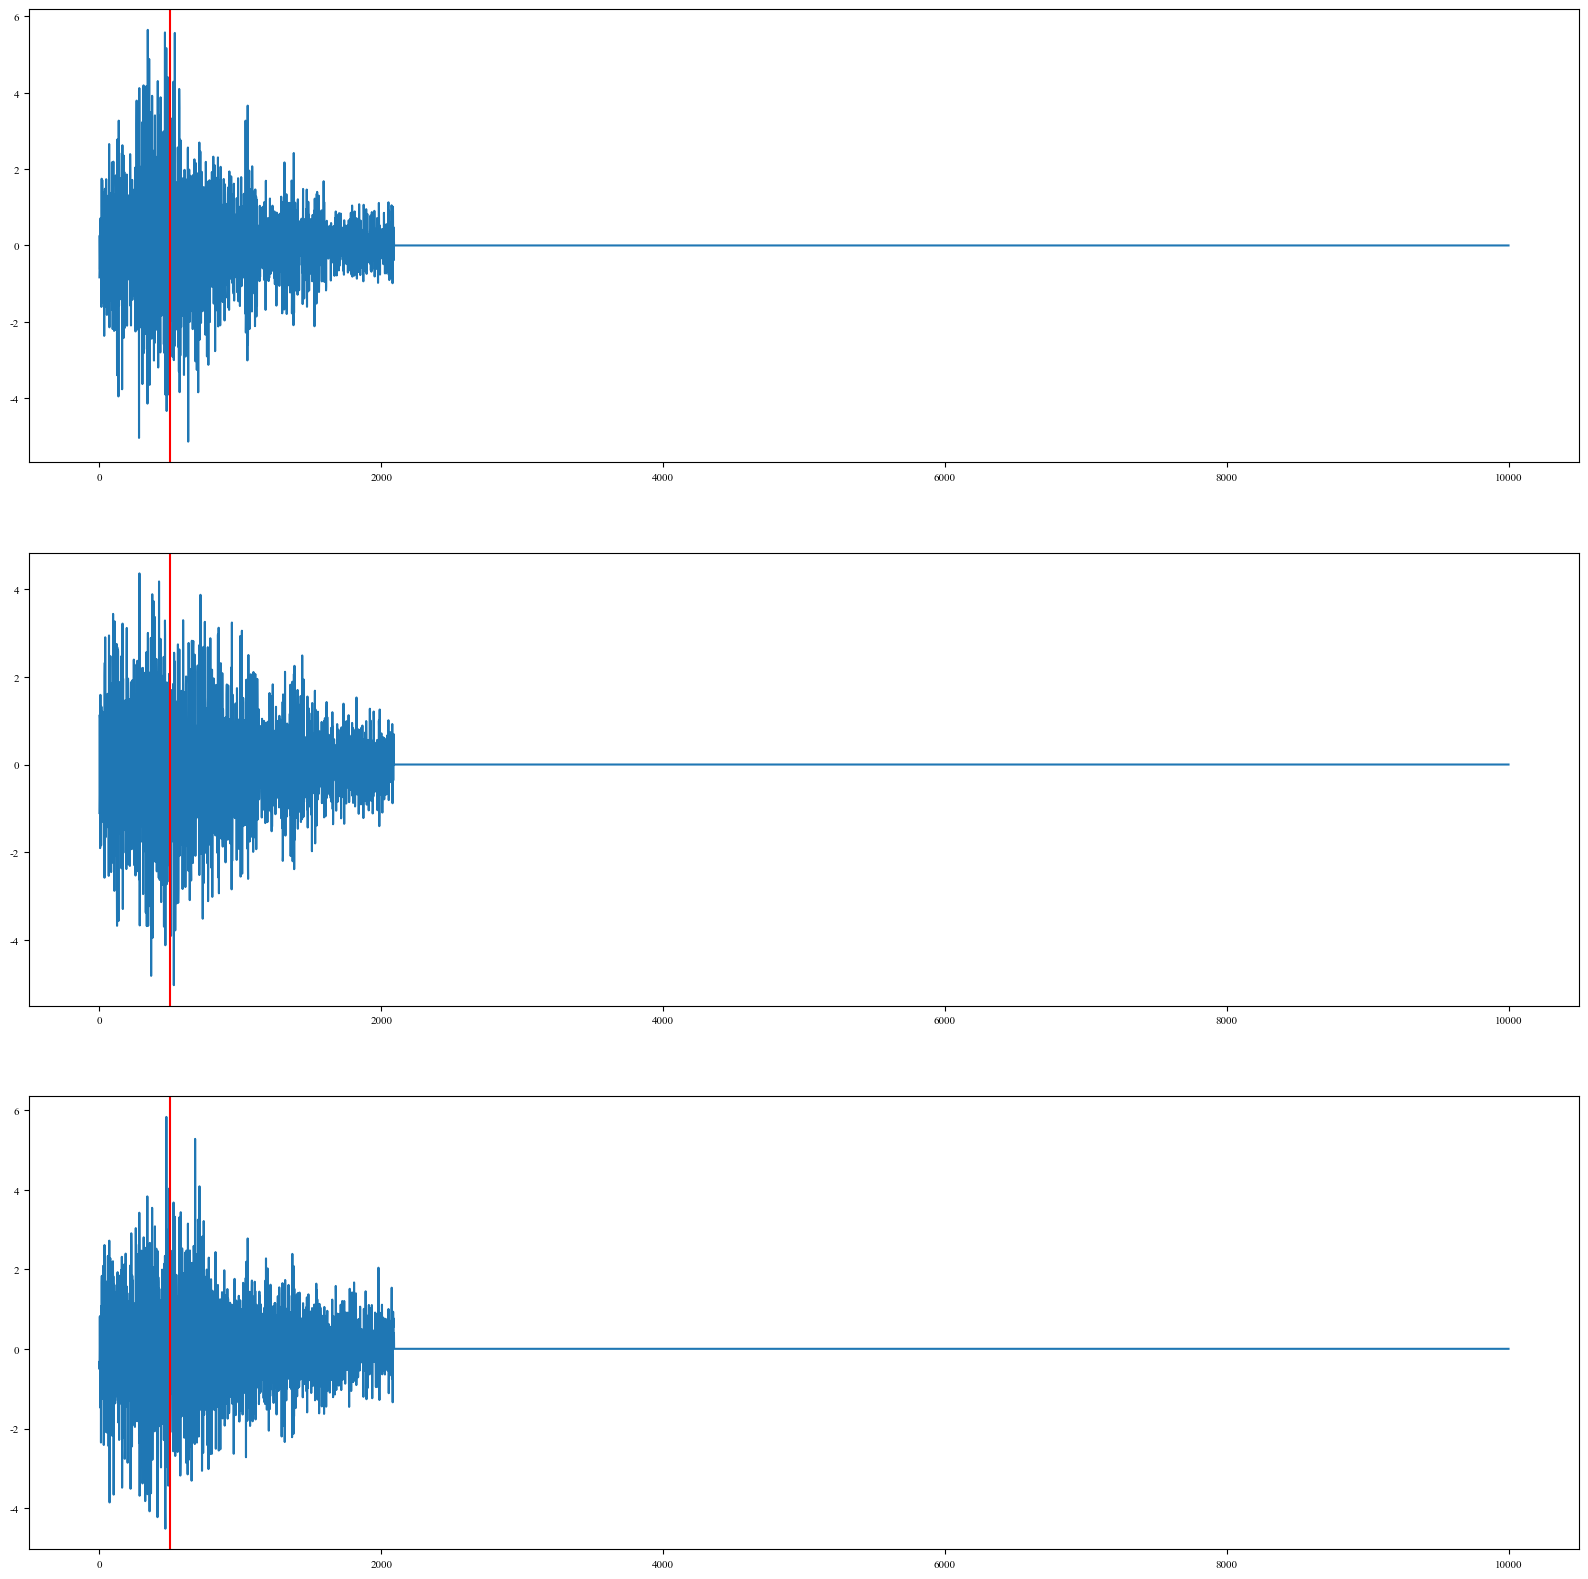

In [114]:
fig, axes = plt.subplots(3,1, figsize=(20,20))
axes[0].plot(inputs[0][ibatch,istation,0].cpu().numpy())
axes[0].axvline(x=picks[ibatch,0,istation], c='r')
axes[1].plot(inputs[0][ibatch,istation,1].cpu().numpy())
axes[1].axvline(x=picks[ibatch,0,istation], c='r')
axes[2].plot(inputs[0][ibatch,istation,2].cpu().numpy())
axes[2].axvline(x=picks[ibatch,0,istation], c='r')
plt.show()
plt.close()

In [43]:
picks[ibatch,0]

tensor([ 1632.,  1785.,   500., 10000., 10000., 10000., 10000., 10000., 10000.,
        10000., 10000., 10000., 10000., 10000., 10000., 10000., 10000., 10000.,
        10000., 10000., 10000., 10000., 10000., 10000., 10000.],
       dtype=torch.float64)

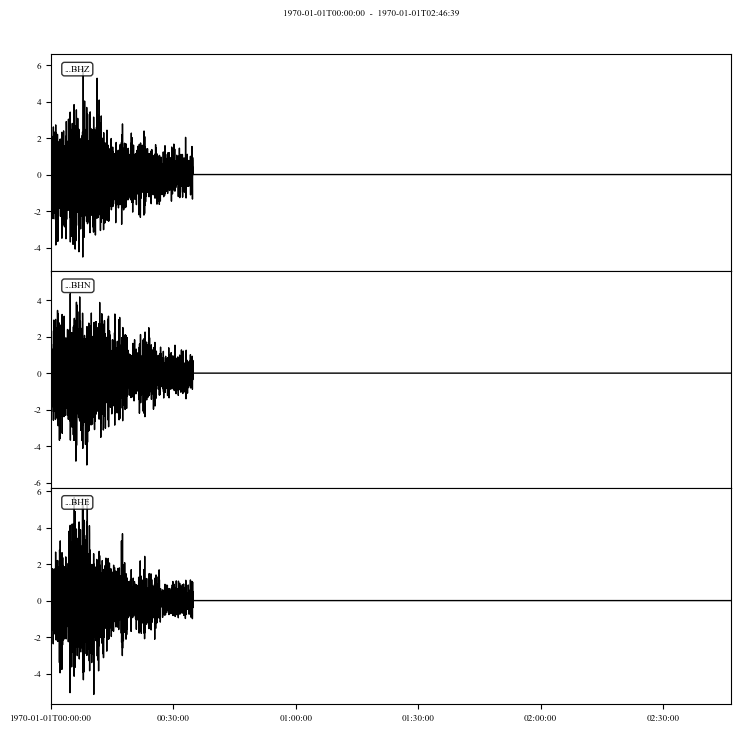

In [46]:
st = obspy.Stream()
st += obspy.Trace(data=inputs[0][ibatch,istation,0].cpu().numpy(), header={'channel':'BHE'})
st += obspy.Trace(data=inputs[0][ibatch,istation,1].cpu().numpy(), header={'channel':'BHN'})
st += obspy.Trace(data=inputs[0][ibatch,istation,2].cpu().numpy(), header={'channel':'BHZ'})
st.plot()
plt.show()
plt.close()

In [22]:
dataset = train_generators[0]

In [61]:
index = 3
indexes = dataset.indexes[index:(index + 1)] 
index = dataset.indexes[index]
ith_event = dataset.event_keys[index]

In [62]:
print(index, ith_event)

73 1870169


In [63]:
with h5py.File(dataset.data_path, 'r') as f:
    event = dataset.event_metadata.get_group(ith_event)
    event_name = str(event[dataset.event_key].iloc[0])
    g_event = f['data'][event_name]
    data = {}
    for key in g_event:
        if dataset.data_keys is not None and key not in dataset.data_keys:
            continue
        if key not in data:
            data[key] = []
        if key == 'waveforms':
            # pad to 10000 points
            cur_waveform = g_event[key][:, ::dataset.decimate, :]
            cur_waveform -= np.mean(cur_waveform, axis=1, keepdims=True)
            std = np.std(cur_waveform, axis=1, keepdims=True) + 1e-8
            cur_waveform = cur_waveform / std 
            if cur_waveform.shape[1] < 10000:
                pad_arr = np.zeros((cur_waveform.shape[0],
                                    10000 - cur_waveform.shape[1],
                                    cur_waveform.shape[2]))
                data[key] += [np.concatenate((cur_waveform, pad_arr),
                                             axis=1)]
            else:
                data[key] += [cur_waveform]
        else:
            data[key] += [g_event[key][()]]
        if key == 'p_picks':
            data[key][-1] //= dataset.decimate


In [64]:
n_rec = len(data['p_picks'][0])
print('n rec: ', n_rec, 'picks: ',data['p_picks'][0])

n rec:  3 picks:  [ 499 1073 1432]


plot 2/3


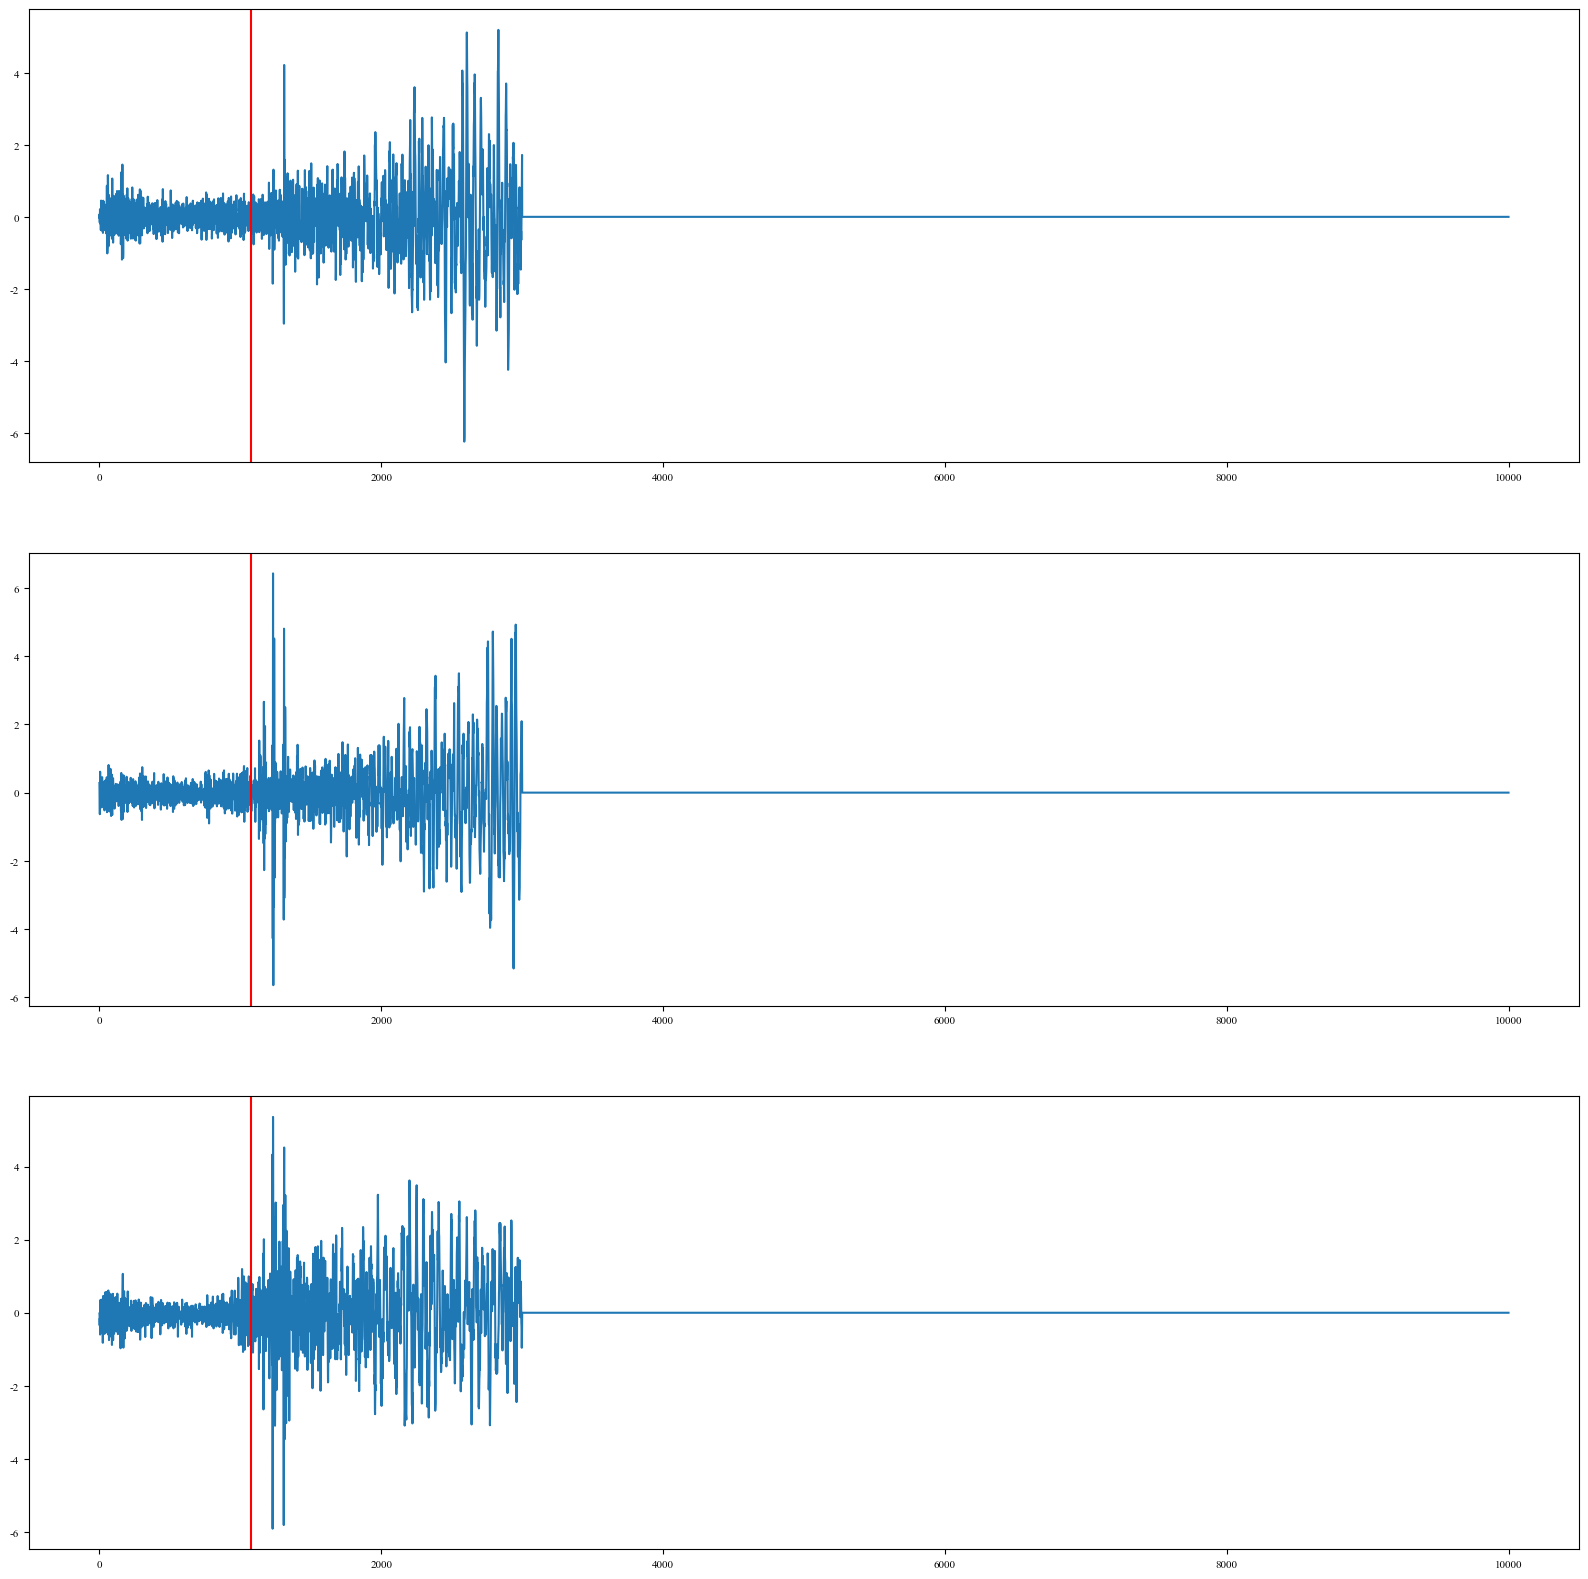

In [71]:
i_rec = 1
print(f'plot {i_rec+1}/{n_rec}')
fig, axes = plt.subplots(3,1, figsize=(20,20))
axes[0].plot(data['waveforms'][0][i_rec,:,0])
axes[0].axvline(x=data['p_picks'][0][i_rec], c='r')
axes[1].plot(data['waveforms'][0][i_rec,:,1])
axes[1].axvline(x=data['p_picks'][0][i_rec], c='r')
axes[2].plot(data['waveforms'][0][i_rec,:,2])
axes[2].axvline(x=data['p_picks'][0][i_rec], c='r')
plt.show()
plt.close()

plot 2/3


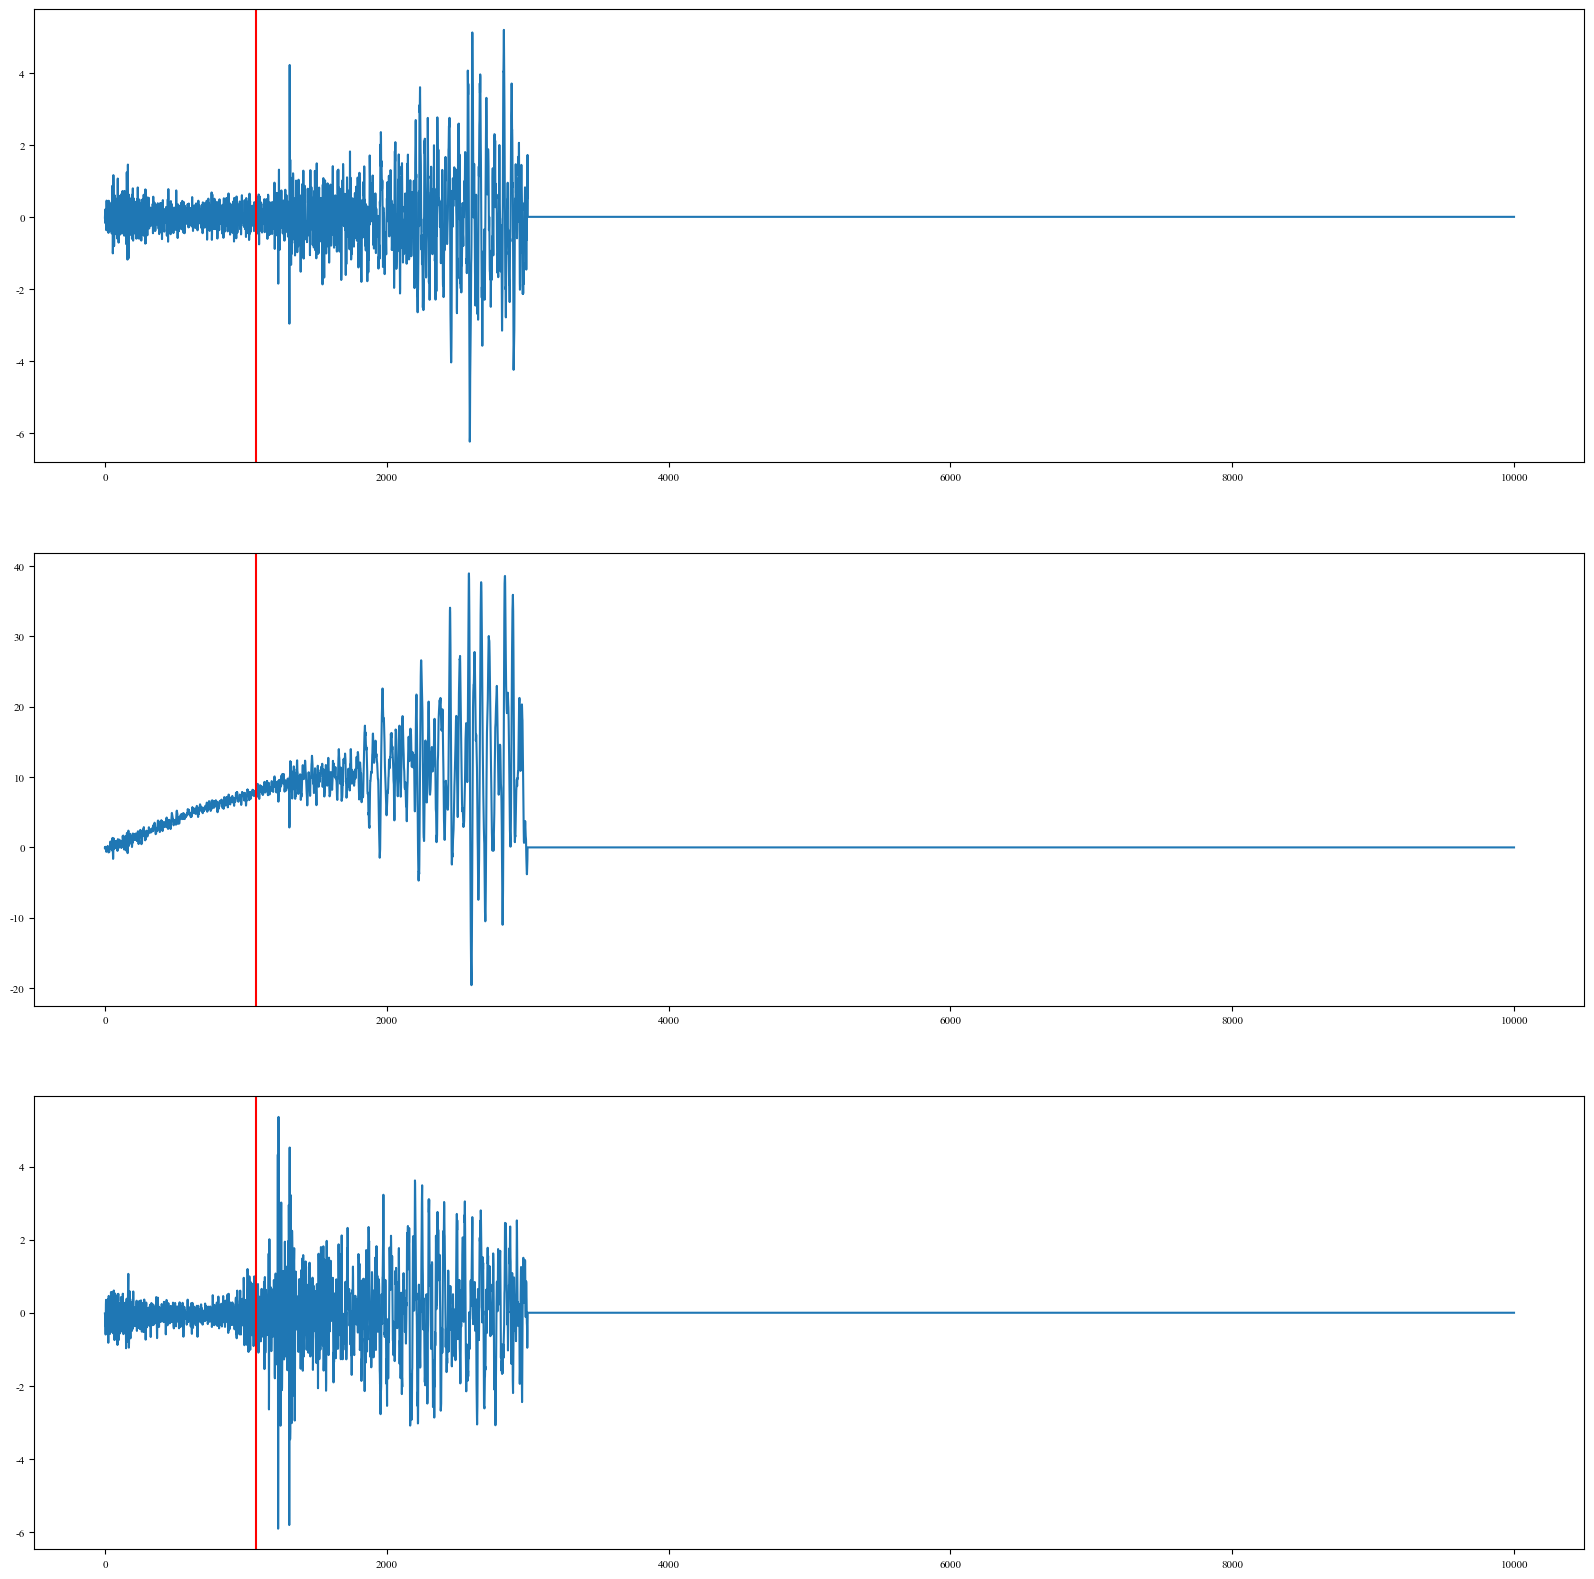

In [72]:
i_rec = 1
print(f'plot {i_rec+1}/{n_rec}')
fig, axes = plt.subplots(3,1, figsize=(20,20))
axes[0].plot(data['waveforms'][0][i_rec,:,0])
axes[0].axvline(x=data['p_picks'][0][i_rec], c='r')
axes[1].plot(data['waveforms'][0][i_rec,:,0].cumsum())
axes[1].axvline(x=data['p_picks'][0][i_rec], c='r')
axes[2].plot(data['waveforms'][0][i_rec,:,2])
axes[2].axvline(x=data['p_picks'][0][i_rec], c='r')
plt.show()
plt.close()